In [ ]:
!pip install vmdpy -q
import numpy as np
import matplotlib.pyplot as plt
from vmdpy import VMD

np.random.seed(0)
fs = 100; T_dur = 2
t = np.linspace(0, T_dur, fs*T_dur)
half = len(t)//2
signal = np.concatenate([
    np.sin(2*np.pi*2*t[:half]),
    np.sin(2*np.pi*8*t[half:])
]) + 0.1*np.random.randn(len(t))

u, u_hat, omega = VMD(signal, 2000, 0.0, 4, 0, 1, 1e-6)

correlations = np.abs([np.corrcoef(signal, u[k])[0,1] for k in range(u.shape[0])])
selected = correlations >= np.median(correlations)
K_prime = selected.sum()
selected_modes = u[selected]
print(f"Seçilen mod sayısı (K'): {K_prime}, sinyal uzunluğu (T): {u.shape[1]}")

Seçilen mod sayısı (K'): 2, sinyal uzunluğu (T): 200


In [ ]:
def n_tau(T, tau, s):
    return (T - tau)//s + 1

T = selected_modes.shape[1]
window_sizes = [20, 40, 80]   # Orantılı küçültülmüş değerler

counts = {}
for k in range(K_prime):
    for tau in window_sizes:
        s = tau//2
        counts[(k, tau)] = n_tau(T, tau, s)

for (k, tau), n in counts.items():
    print(f"Mod {k+1}, τ={tau}: {n} pencere")

total_segments = sum(counts.values())
print(f"\nTOPLAM SEGMENT SAYISI: {total_segments}")

Mod 1, τ=20: 19 pencere
Mod 1, τ=40: 9 pencere
Mod 1, τ=80: 4 pencere
Mod 2, τ=20: 19 pencere
Mod 2, τ=40: 9 pencere
Mod 2, τ=80: 4 pencere

TOPLAM SEGMENT SAYISI: 64


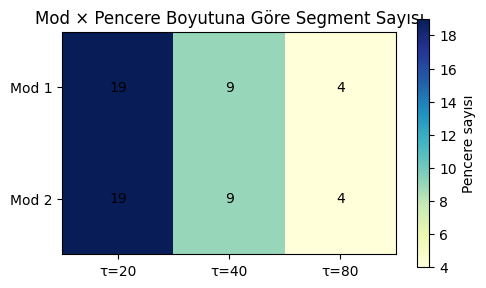

In [ ]:
count_matrix = np.array([[counts[(k,tau)] for tau in window_sizes] for k in range(K_prime)])

fig, ax = plt.subplots(figsize=(5,3))
im = ax.imshow(count_matrix, cmap='YlGnBu')
ax.set_xticks(range(len(window_sizes))); ax.set_xticklabels([f"τ={t}" for t in window_sizes])
ax.set_yticks(range(K_prime)); ax.set_yticklabels([f"Mod {k+1}" for k in range(K_prime)])
for i in range(K_prime):
    for j in range(len(window_sizes)):
        ax.text(j, i, count_matrix[i,j], ha='center', va='center')
ax.set_title("Mod × Pencere Boyutuna Göre Segment Sayısı")
fig.colorbar(im, ax=ax, label="Pencere sayısı")
plt.tight_layout(); plt.show()

In [ ]:
def multi_grained_windows(mode_signal, window_size, stride):
    N = (len(mode_signal) - window_size)//stride + 1
    return np.array([mode_signal[i*stride:i*stride+window_size] for i in range(N)])

all_segments = {}   # anahtar: (k, tau, i) -> segment dizisi
for k in range(K_prime):
    for tau in window_sizes:
        s = tau//2
        windows = multi_grained_windows(selected_modes[k], tau, s)
        for i, w in enumerate(windows):
            all_segments[(k, tau, i)] = w

print("Toplam üretilen segment sayısı (dict boyutu):", len(all_segments))
print("Örnek bir anahtar (mod=0, τ=40, pencere=3):", all_segments[(0, 40, 3)].shape)

Toplam üretilen segment sayısı (dict boyutu): 64
Örnek bir anahtar (mod=0, τ=40, pencere=3): (40,)


In [ ]:
print(f"Ders 12'de her biri için AYRI bir Granger causality testi yapılacak segment sayısı: {len(all_segments)}")
print(f"Ders 13'de her biri için AYRI bir local graph + GAT işlemi yapılacak segment sayısı: {len(all_segments)}")
print(f"\n(Gerçek EEG'de C=32 kanal olduğu için her segment aslında (C, τ) boyutunda, yani")
print(f" Granger causality her segment için C×C = {32*32} çift kanal ilişkisi hesaplayacak!)")

Ders 17'de her biri için AYRI bir Granger causality testi yapılacak segment sayısı: 64
Ders 18'de her biri için AYRI bir local graph + GAT işlemi yapılacak segment sayısı: 64

(Gerçek EEG'de C=32 kanal olduğu için her segment aslında (C, τ) boyutunda, yani
 Granger causality her segment için C×C = 1024 çift kanal ilişkisi hesaplayacak!)
